# 02 — 16S Taxonomy Processing

**Run All** (or run each cell top → bottom with Shift+Enter).

| Step | What |
|------|------|
| 1 | Setup — paths |
| 2 | Load TSV, parse taxonomy → genus counts |
| 3 | Relative abundance, diversity, aggregate replicates by (date, reactor) |
| 4 | Feature selection + export CSV |
| 5 | Plot top genera (2025) |

**Input:** `data/raw/Prof_Miller_16S/2025_Fall_16S_GB_table-with-taxonomy.tsv`  
**Output:** `data/processed/16S_genus_by_date_reactor.csv`  

Note: sample columns span **2022–2025** (not only Fall 2025).

## Step 1 — Setup

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()
TSV_PATH = PROJECT_ROOT / "data/raw/Prof_Miller_16S/2025_Fall_16S_GB_table-with-taxonomy.tsv"
OUT_DIR = PROJECT_ROOT / "data/processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not TSV_PATH.exists():
    raise FileNotFoundError(TSV_PATH)

# Hypothesis genera (H1–H3) — extend as needed
HYPOTHESIS_GENERA = [
    "Nitrospira_D",
    "Nitrospira",
    "Pseudonocardia",
    "Nitrosocosmicus",
    "Nitrosomonas",
]

MIN_READS_PER_SAMPLE = 5000  # QC threshold from execution plan
TOP_K_GENERA = 15

print("Project root:", PROJECT_ROOT)
print("TSV:", TSV_PATH)

Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY
TSV: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/raw/Prof_Miller_16S/2025_Fall_16S_GB_table-with-taxonomy.tsv


## Step 2 — Load TSV & parse taxonomy

In [2]:
def parse_taxonomy(tax_string: str) -> dict:
    """Extract g__ genus from Silva-style taxonomy string."""
    levels = {}
    for part in str(tax_string).split(";"):
        part = part.strip()
        if "__" in part:
            prefix, name = part.split("__", 1)
            levels[prefix] = name.strip() or None
    genus = levels.get("g")
    family = levels.get("f")
    if not genus or genus in ("", "None"):
        genus = family if family else "Unknown"
    return {"genus": genus, "family": family, "phylum": levels.get("p")}


def parse_sample_id(sample_id: str) -> dict:
    """Parse e.g. 25-04-01_R1_N1_B_1 → date, reactor, sample_id."""
    m = re.match(r"(\d{2})-(\d{2})-(\d{2})_R(\d)", sample_id)
    if not m:
        return {"sample_id": sample_id, "date": None, "reactor": None}
    yy, mm, dd, r = m.groups()
    return {
        "sample_id": sample_id,
        "date": pd.Timestamp(f"20{yy}-{mm}-{dd}"),
        "reactor": f"R{r}",
    }


# Skip comment line (# Constructed from biom file)
raw = pd.read_csv(TSV_PATH, sep="\t", skiprows=1, low_memory=False)
otu_col = raw.columns[0]
taxonomy_col = raw.columns[-1]
sample_cols = [c for c in raw.columns if c not in (otu_col, taxonomy_col)]

tax_parsed = raw[taxonomy_col].apply(parse_taxonomy).apply(pd.Series)
raw["genus"] = tax_parsed["genus"]

print(f"ASV rows: {len(raw)}")
print(f"Sample columns: {len(sample_cols)}")
print(f"Unique genera: {raw['genus'].nunique()}")

meta = pd.DataFrame([parse_sample_id(c) for c in sample_cols])
meta["total_reads"] = raw[sample_cols].sum(axis=0).values
print("\nSample metadata (first 10):")
print(meta.head(10).to_string(index=False))
print(f"\nSamples below {MIN_READS_PER_SAMPLE} reads:", (meta["total_reads"] < MIN_READS_PER_SAMPLE).sum())

ASV rows: 678
Sample columns: 61
Unique genera: 289

Sample metadata (first 10):
         sample_id       date reactor  total_reads
22-06-14_R1_N1_A_1 2022-06-14      R1     158804.0
22-06-14_R1_N1_D_1 2022-06-14      R1       3954.0
22-06-14_R2_N4_B_1 2022-06-14      R2       1664.0
23-02-28_R1_N4_A_1 2023-02-28      R1       4396.0
23-02-28_R1_N4_B_1 2023-02-28      R1      62784.0
23-02-28_R1_N4_D_1 2023-02-28      R1       9954.0
23-02-28_R2_N4_D_1 2023-02-28      R2      23165.0
23-10-03_R1_N1_A_1 2023-10-03      R1      95384.0
23-10-03_R1_N1_D_1 2023-10-03      R1     100050.0
23-10-03_R1_N2_C_1 2023-10-03      R1      28352.0

Samples below 5000 reads: 7


## Step 3 — Genus relative abundance & aggregate replicates

In [3]:
def shannon(series: pd.Series) -> float:
    p = series[series > 0]
    if p.empty:
        return 0.0
    p = p / p.sum()
    return float(-(p * np.log(p)).sum())


# Genus count matrix: rows=genus, cols=sample
genus_counts = raw.groupby("genus")[sample_cols].sum()

# Relative abundance per sample (column-normalize)
col_sums = genus_counts.sum(axis=0).replace(0, np.nan)
genus_rel = genus_counts.div(col_sums, axis=1).fillna(0)

# Long format with metadata
long = genus_rel.reset_index().melt(id_vars="genus", var_name="sample_id", value_name="rel_abundance")
long = long.merge(meta, on="sample_id", how="left")
long = long.dropna(subset=["date", "reactor"])

# QC: drop low-read samples
passing_samples = set(meta.loc[meta["total_reads"] >= MIN_READS_PER_SAMPLE, "sample_id"])
long_qc = long[long["sample_id"].isin(passing_samples)].copy()

# Mean relative abundance per (date, reactor) across technical replicates
by_date_reactor = (
    long_qc.groupby(["date", "reactor", "genus"], as_index=False)["rel_abundance"].mean()
)

# Diversity per (date, reactor)
diversity = (
    by_date_reactor.groupby(["date", "reactor"])
    .apply(lambda g: pd.Series({
        "shannon": shannon(g.set_index("genus")["rel_abundance"]),
        "richness": (g["rel_abundance"] > 0).sum(),
    }))
    .reset_index()
)

wide = by_date_reactor.pivot_table(
    index=["date", "reactor"], columns="genus", values="rel_abundance", fill_value=0
).reset_index()

wide = wide.merge(diversity, on=["date", "reactor"], how="left")

dates = sorted(wide["date"].unique())
print(f"Rows after QC + replicate mean: {len(wide)} (date, reactor) pairs")
print(f"Unique dates: {len(dates)} -> {[d.strftime('%Y-%m-%d') for d in dates]}")
print(f"Reactors per date:")
print(wide.groupby("date")["reactor"].apply(list).to_string())

wide_2025 = wide[wide["date"].dt.year == 2025]
print(f"\n2025 rows: {len(wide_2025)}")

Rows after QC + replicate mean: 12 (date, reactor) pairs
Unique dates: 10 -> ['2022-06-14', '2023-02-28', '2023-10-03', '2025-01-07', '2025-02-25', '2025-04-01', '2025-04-29', '2025-05-21', '2025-06-24', '2025-07-22']
Reactors per date:
date
2022-06-14        [R1]
2023-02-28    [R1, R2]
2023-10-03    [R1, R2]
2025-01-07        [R1]
2025-02-25        [R1]
2025-04-01        [R1]
2025-04-29        [R1]
2025-05-21        [R1]
2025-06-24        [R1]
2025-07-22        [R1]

2025 rows: 7


## Step 4 — Feature selection & export

In [4]:
# Top K genera by mean relative abundance (across all samples)
genus_cols = [c for c in wide.columns if c not in ("date", "reactor", "shannon", "richness")]
mean_abund = wide[genus_cols].mean().sort_values(ascending=False)
top_genera = list(mean_abund.head(TOP_K_GENERA).index)

# Ensure hypothesis genera included if present in data
feature_genera = list(dict.fromkeys(top_genera + [g for g in HYPOTHESIS_GENERA if g in genus_cols]))

export_cols = ["date", "reactor", "shannon", "richness"] + feature_genera
export_df = wide[export_cols].copy()

# Also save wide genus table (all genera) for PCA
out_features = OUT_DIR / "16S_genus_by_date_reactor.csv"
out_full = OUT_DIR / "16S_genus_by_date_reactor_full.csv"
export_df.to_csv(out_features, index=False)
wide.to_csv(out_full, index=False)

print(f"Feature genera ({len(feature_genera)}):", feature_genera[:10], "...")
print(f"\nSaved (features): {out_features}")
print(f"Saved (all genera): {out_full}")
print("\n2025 preview:")
print(export_df[export_df["date"].dt.year == 2025].to_string(index=False))

Feature genera (15): ['Nitrospira_D', 'Unknown', 'Nitrosocosmicus', 'Pseudonocardia', 'Hyphomicrobium_C', 'Rugosibacter', 'Burkholderiaceae_A_595421', 'Hyphococcus', 'CR02bin9', 'Nitrospira_A'] ...

Saved (features): /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/16S_genus_by_date_reactor.csv
Saved (all genera): /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/16S_genus_by_date_reactor_full.csv

2025 preview:
      date reactor  shannon  richness  Nitrospira_D  Unknown  Nitrosocosmicus  Pseudonocardia  Hyphomicrobium_C  Rugosibacter  Burkholderiaceae_A_595421  Hyphococcus  CR02bin9  Nitrospira_A  UBA5704    M3007  JABDJB01   HGW-15  Hyphomicrobiaceae
2025-01-07      R1 3.557341     141.0      0.144738 0.079404         0.132409        0.054399          0.045901      0.014070                   0.014488     0.030368  0.053493      0.015045 0.014418 0.005224  0.010378 0.013722           0.021174
2025-02-25      R1 3.749741     248.0      0.172323 0.167382         0.

## Step 5 — Plot top genera (2025)

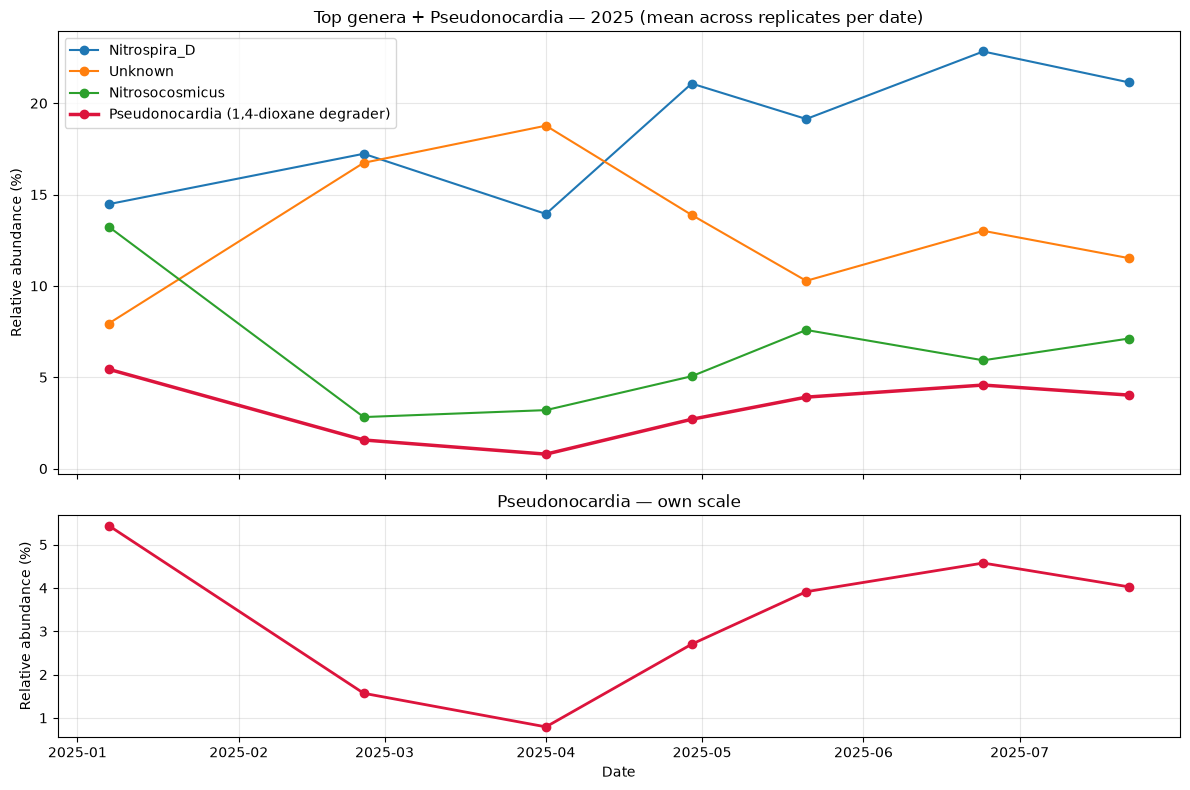

Pseudonocardia 2025 relative abundance (%):
date
2025-01-07    5.440
2025-02-25    1.568
2025-04-01    0.793
2025-04-29    2.701
2025-05-21    3.913
2025-06-24    4.575
2025-07-22    4.024


In [5]:
DEGRADER = "Pseudonocardia"

# Top 3 by abundance, plus the dioxane degrader regardless of its rank
plot_genera = [g for g in top_genera[:3] if g in export_df.columns]
if DEGRADER in export_df.columns and DEGRADER not in plot_genera:
    plot_genera.append(DEGRADER)

plot_df = export_df[export_df["date"].dt.year == 2025].copy()

if plot_df.empty:
    print("No 2025 rows to plot.")
else:
    fig, (ax, ax_deg) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )

    for genus in plot_genera:
        sub = plot_df.groupby("date", as_index=False)[genus].mean()
        is_degrader = genus == DEGRADER
        ax.plot(
            sub["date"], sub[genus] * 100,
            marker="o",
            linewidth=2.5 if is_degrader else 1.5,
            color="crimson" if is_degrader else None,
            zorder=3 if is_degrader else 2,
            label=f"{genus} (1,4-dioxane degrader)" if is_degrader else genus,
        )
    ax.set_ylabel("Relative abundance (%)")
    ax.set_title("Top genera + Pseudonocardia — 2025 (mean across replicates per date)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Degrader alone: on the shared axis above it spans <6% and reads as flat
    deg = plot_df.groupby("date", as_index=False)[DEGRADER].mean()
    ax_deg.plot(deg["date"], deg[DEGRADER] * 100, marker="o", color="crimson", linewidth=2)
    ax_deg.set_ylabel("Relative abundance (%)")
    ax_deg.set_xlabel("Date")
    ax_deg.set_title(f"{DEGRADER} — own scale")
    ax_deg.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"{DEGRADER} 2025 relative abundance (%):")
    print((deg.set_index("date")[DEGRADER] * 100).round(3).to_string())